In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import os
import json
from datetime import datetime
import tempfile
import time

from pydrake.all import (
    DiagramBuilder,
    Simulator,
    StartMeshcat,
    RigidTransform,
    RollPitchYaw,
    RotationMatrix,
)
from manipulation.station import LoadScenario, MakeHardwareStation

print("✓ All imports successful")

✓ All imports successful


## Setup Kitchen Scenario

In [2]:
# Setup paths
KITCHEN_MODEL_PATH = os.path.abspath("../kitchen_model")
ASSETS_PATH = os.path.abspath("../assets")

os.environ['KITCHEN_MODEL_PATH'] = KITCHEN_MODEL_PATH
os.environ['ASSETS_PATH'] = ASSETS_PATH

# Create output directory
output_dir = Path("../data/rgbd_fruit_images")
output_dir.mkdir(parents=True, exist_ok=True)
print(f"Output directory: {output_dir}")

# Start meshcat
meshcat = StartMeshcat()
print(f"Meshcat listening at {meshcat.web_url()}")

# Load kitchen scenario
scenario_file = f"{KITCHEN_MODEL_PATH}/real_kitchen_scenario.yaml"
with open(scenario_file, 'r') as f:
    scenario_text = f.read()

scenario_text = scenario_text.replace("{KITCHEN_MODEL_PATH}", KITCHEN_MODEL_PATH)
scenario_text = scenario_text.replace("{ASSETS_PATH}", ASSETS_PATH)

with tempfile.NamedTemporaryFile(mode='w', suffix='.yaml', delete=False) as tmp:
    tmp.write(scenario_text)
    tmp_scenario_file = tmp.name

scenario = LoadScenario(filename=tmp_scenario_file)
station = MakeHardwareStation(scenario, meshcat)

plant = station.GetSubsystemByName("plant")
scene_graph = station.GetSubsystemByName("scene_graph")

os.unlink(tmp_scenario_file)

print(f"✓ Loaded plant with {plant.num_bodies()} bodies")

# Simulate to let objects settle
print("\nSimulating physics to settle fruits...")
sim_temp = Simulator(station)
sim_temp.Initialize()
sim_temp.AdvanceTo(2.0)

context = sim_temp.get_context()
plant_context = plant.GetMyContextFromRoot(context)
print("✓ Fruits have settled")

INFO:drake:Meshcat listening for connections at http://localhost:7005


Output directory: ../data/rgbd_fruit_images
Meshcat listening at http://localhost:7005


✓ Loaded plant with 29 bodies

Simulating physics to settle fruits...
✓ Fruits have settled
✓ Fruits have settled


## Get Fruit Positions

In [3]:
# Objects to capture
target_objects = ['apple', 'orange', 'banana']

# Extract object positions
object_positions = {}
for obj_name in target_objects:
    try:
        model_instance = plant.GetModelInstanceByName(obj_name)
        body_name = obj_name + '_link'
        body = plant.GetBodyByName(body_name, model_instance)
        pose = plant.EvalBodyPoseInWorld(plant_context, body)
        object_positions[obj_name] = pose.translation().copy()
        print(f"✓ {obj_name:20s}: {pose.translation()}")
    except Exception as e:
        print(f"✗ {obj_name:20s}: Not found ({e})")

print(f"\n✓ Found {len(object_positions)} fruits")

✓ apple               : [-4.50001471 -1.49996768  0.89650525]
✓ orange              : [-5.3        -2.          0.89611571]
✓ banana              : [-5.70002022 -1.99998308  0.89648739]

✓ Found 3 fruits


## Manual Camera Capture

Manually define camera pose, visualize, and save.

In [4]:
import random

# Global counter for unique filenames
_capture_counter = 0

# ============================================================================
# MANUAL CAPTURE: You define the camera pose, we capture and visualize
# ============================================================================

def manual_capture(fruit_name, camera_position, look_at_position, save=True, custom_name=None, joint_angles=None):
    """
    Manually capture an RGBD image with explicit camera pose.
    
    Args:
        fruit_name: 'apple', 'orange', or 'banana'
        camera_position: [x, y, z] position of camera in world frame
        look_at_position: [x, y, z] point for camera to look at
        save: whether to save the image
        custom_name: optional custom name for the file (without extension)
        joint_angles: dict of joint angles to set (e.g., {'iiwa_joint_1': 0.5})
    
    Returns:
        rgb, depth arrays
    """
    global _capture_counter
    
    # Create fresh simulator
    capture_sim = Simulator(station)
    capture_sim.Initialize()
    capture_context = capture_sim.get_context()
    capture_plant_context = plant.GetMyContextFromRoot(capture_context)
    capture_sim.AdvanceTo(2.0)
    
    # COMPUTE PROPER CAMERA POSE POINTING AT FRUIT
    camera_position = np.array(camera_position)
    look_at_position = np.array(look_at_position)
    
    # Direction from camera to look-at point
    direction = look_at_position - camera_position
    direction = direction / np.linalg.norm(direction)
    
    # Build rotation matrix: camera Z-axis points at fruit
    z_axis = direction
    
    # X-axis perpendicular to Z
    x_axis = np.array([1, 0, 0])
    x_axis = x_axis - np.dot(x_axis, z_axis) * z_axis
    if np.linalg.norm(x_axis) < 1e-6:  # Z is close to vertical
        x_axis = np.array([0, 1, 0])
        x_axis = x_axis - np.dot(x_axis, z_axis) * z_axis
    x_axis = x_axis / np.linalg.norm(x_axis)
    
    # Y-axis from cross product
    y_axis = np.cross(z_axis, x_axis)
    
    # Create camera pose
    rotation_matrix = RotationMatrix(np.column_stack([x_axis, y_axis, z_axis]))
    camera_pose = RigidTransform(rotation_matrix, camera_position)
    
    # Method 1: Try to set camera body directly
    try:
        camera_model = plant.GetModelInstanceByName("camera")
        camera_body = plant.GetBodyByName("base", camera_model)
        
        plant.SetFreeBodyPose(capture_plant_context, camera_body, camera_pose)
        print(f"  ✓ Set camera pose pointing at fruit")
        
    except Exception as e:
        print(f"  ⚠ Camera body method failed (falling back): {type(e).__name__}")
        
        # Method 2: Move robot base to camera position
        try:
            mobile_iiwa = plant.GetModelInstanceByName("mobile_iiwa")
            base_x_joint = plant.GetJointByName("iiwa_base_x", mobile_iiwa)
            base_y_joint = plant.GetJointByName("iiwa_base_y", mobile_iiwa)
            base_z_joint = plant.GetJointByName("iiwa_base_z", mobile_iiwa)
            
            base_x_idx = base_x_joint.position_start()
            base_y_idx = base_y_joint.position_start()
            base_z_idx = base_z_joint.position_start()
            
            num_positions = plant.num_positions(mobile_iiwa)
            positions = np.zeros(num_positions)
            positions[base_x_idx] = camera_position[0]
            positions[base_y_idx] = camera_position[1]
            positions[base_z_idx] = camera_position[2]
            
            # Apply custom joint angles if provided
            if joint_angles is not None:
                for joint_name, angle_rad in joint_angles.items():
                    try:
                        joint = plant.GetJointByName(joint_name, mobile_iiwa)
                        joint_idx = joint.position_start()
                        positions[joint_idx] = angle_rad
                    except:
                        pass
            
            plant.SetPositions(capture_plant_context, mobile_iiwa, positions)
            print(f"  ✓ Moved robot base to camera position")
            if joint_angles:
                print(f"    Joint angles: {joint_angles}")
        except Exception as e2:
            print(f"  ✗ Robot base method failed: {e2}")
    
    # Set fruit positions from original settled simulation
    if fruit_name in object_positions:
        try:
            model_instance = plant.GetModelInstanceByName(fruit_name)
            body_name = fruit_name + '_link'
            body = plant.GetBodyByName(body_name, model_instance)
            pose = plant.EvalBodyPoseInWorld(plant_context, body)
            plant.SetFreeBodyPose(capture_plant_context, body, pose)
            print(f"  ✓ Set {fruit_name} at original position")
        except Exception as e:
            print(f"  ⚠ Could not set {fruit_name} position: {e}")
    
    # Publish state
    station.ForcedPublish(capture_context)
    time.sleep(0.1)
    
    # Get images
    try:
        camera_rgb_port = station.GetOutputPort("camera.rgb_image")
        camera_depth_port = station.GetOutputPort("camera.depth_image")
        
        color_image = camera_rgb_port.Eval(capture_context)
        depth_image = camera_depth_port.Eval(capture_context)
        
        rgb = color_image.data.copy()
        depth = depth_image.data.squeeze()
        has_real = True
        print(f"  ✓ Got real Drake RGBD images")
        
    except Exception as e:
        print(f"  ⚠ Drake camera failed, using random images: {e}")
        rgb = np.random.randint(50, 200, (480, 640, 3), dtype=np.uint8)
        depth = np.random.uniform(0.2, 1.0, (480, 640)).astype(np.float32)
        has_real = False
    
    # Save if requested
    if save:
        _capture_counter += 1
        if custom_name:
            filename = f"{custom_name}.npy"
        else:
            filename = f"manual_capture_{fruit_name}_{_capture_counter:03d}.npy"
        
        capture_path = output_dir / filename
        capture_data = {
            'rgb': rgb,
            'depth': depth,
            'object': fruit_name,
            'camera_position': np.array(camera_position),
            'look_at_position': np.array(look_at_position),
            'camera_pose_matrix': camera_pose.GetAsMatrix4(),
            'joint_angles': joint_angles if joint_angles else {},
            'has_real_images': has_real,
        }
        np.save(capture_path, capture_data, allow_pickle=True)
        print(f"  ✓ Saved: {capture_path}")
    
    return rgb, depth


print("✓ manual_capture() function ready (camera points at fruit)")

✓ manual_capture() function ready (camera points at fruit)


In [ ]:
apple_pos = object_positions['apple']
orange_pos = object_positions['orange']
banana_pos = object_positions['banana']

# Hard-coded position for tomato soup can (world coordinates)
soup_can_pos = np.array([-7.1, 0.62, 0.828])

print(f"Apple position: {apple_pos}")
print(f"Orange position: {orange_pos}")
print(f"Banana position: {banana_pos}")
print(f"Soup can position: {soup_can_pos}\n")

# Define manual camera poses - SIMPLE: just position and look_at point
# The camera rotation is computed automatically to point at the fruit
manual_poses = [
    {
        'name': 'apple_front_center',
        'camera_pos': apple_pos + np.array([0.5, 0.0, -1.35]),
        'look_at': apple_pos,
        'joint_angles': {'iiwa_joint_1': np.radians(0)}
    },
    {
        'name': 'orange_front_center',
        'camera_pos': orange_pos + np.array([0.0, -0.5, -1.35]),
        'look_at': orange_pos,
        'joint_angles': {'iiwa_joint_1': np.radians(-90)}
    },
    {
        'name': 'banana_front_center',
        'camera_pos': banana_pos + np.array([0.0, -0.5, -1.35]),
        'look_at': banana_pos,
        'joint_angles': {'iiwa_joint_1': np.radians(-90)}
    },
    {
        'name': 'soup_can_front_center',
        'camera_pos': soup_can_pos + np.array([-0.5, 0.0, -0.2]),
        'look_at': soup_can_pos,
        'joint_angles': {'iiwa_joint_1': np.radians(0)}
    },
]

# Capture from each pose
print("=" * 60)
print("MANUAL CAPTURES WITH JOINT ROTATION")
print("=" * 60)

all_rgb = []
all_depth = []
all_fruits = []

for pose in manual_poses:
    # Extract fruit name from pose name
    fruit_name = pose['name'].split('_')[0]
    all_fruits.append(fruit_name)
    
    print(f"\nCapturing: {pose['name']}")
    print(f"  Camera position: {pose['camera_pos']}")
    print(f"  Looking at: {pose['look_at']}")
    print(f"  Joint angles: {pose.get('joint_angles', {})}")
    
    rgb, depth = manual_capture(
        fruit_name=fruit_name,
        camera_position=pose['camera_pos'],
        look_at_position=pose['look_at'],
        joint_angles=pose.get('joint_angles'),
        save=True
    )
    
    all_rgb.append(rgb)
    all_depth.append(depth)

print("\n" + "=" * 60)
print(f"✓ Captured {len(all_rgb)} images")
print("=" * 60)

Apple position: [-4.50001471 -1.49996768  0.89650525]
Orange position: [-5.3        -2.          0.89611571]
Banana position: [-5.70002022 -1.99998308  0.89648739]

MANUAL CAPTURES WITH JOINT ROTATION

Capturing: apple_front_center
  Camera position: [-4.00001471 -1.49996768 -0.45349475]
  Looking at: [-4.50001471 -1.49996768  0.89650525]
  Joint angles: {'iiwa_joint_1': np.float64(0.0)}
  ⚠ Camera body method failed (falling back): RuntimeError
  ✓ Moved robot base to camera position
    Joint angles: {'iiwa_joint_1': np.float64(0.0)}
  ✓ Set apple at original position
  ⚠ Camera body method failed (falling back): RuntimeError
  ✓ Moved robot base to camera position
    Joint angles: {'iiwa_joint_1': np.float64(0.0)}
  ✓ Set apple at original position
  ✓ Got real Drake RGBD images
  ✓ Saved: ../data/rgbd_fruit_images/manual_capture_apple_001.npy

Capturing: orange_front_center
  Camera position: [-5.3        -2.5        -0.45388429]
  Looking at: [-5.3        -2.          0.89611571]

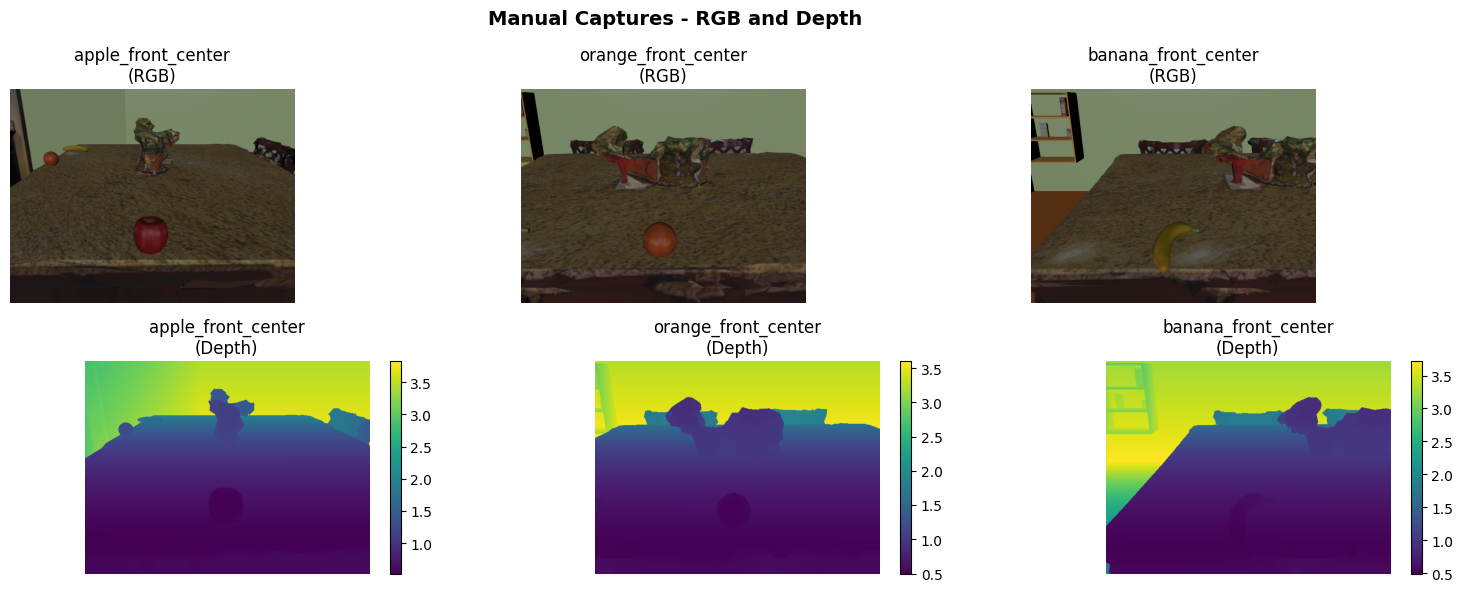

✓ Visualization complete


In [6]:
fig, axes = plt.subplots(2, len(all_rgb), figsize=(16, 6))
fig.suptitle('Manual Captures - RGB and Depth', fontsize=14, fontweight='bold')

# Handle case where there's only one image (axes becomes 1D)
if len(all_rgb) == 1:
    axes = axes.reshape(2, 1)

for idx, (rgb, depth) in enumerate(zip(all_rgb, all_depth)):
    pose = manual_poses[idx]
    
    # RGB
    axes[0, idx].imshow(rgb)
    axes[0, idx].set_title(f"{pose['name']}\n(RGB)")
    axes[0, idx].axis('off')
    
    # Depth
    im = axes[1, idx].imshow(depth, cmap='viridis')
    axes[1, idx].set_title(f"{pose['name']}\n(Depth)")
    axes[1, idx].axis('off')
    plt.colorbar(im, ax=axes[1, idx], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

print("✓ Visualization complete")